In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import itertools
import warnings
warnings.filterwarnings("ignore")

In [2]:
tf.random.set_seed(42)
SEED = 42

## Dataset path

In [3]:
DATA_DIR = 'dataset'
TRAIN_DIR =os.path.join(DATA_DIR,"train")
TEST_DIR =os.path.join(DATA_DIR,"test")
VAL_DIR =os.path.join(DATA_DIR,"val")

print("Train:",TRAIN_DIR)
print("val:",VAL_DIR)
print("Test:",TEST_DIR)

Train: dataset\train
val: dataset\val
Test: dataset\test


## Check Class Distribution

In [4]:
def count_images(folder):
    classes = sorted(os.listdir(folder))
    counts = {}
    for c in classes:
        p = os.path.join(folder, c)
        if os.path.isdir(p):
            counts[c] = len(os.listdir(p))
    return counts

## Visualize Random Images

In [5]:
def show_random_images(folder, n=8):
    classes = sorted([c for c in os.listdir(folder) if os.path.isdir(os.path.join(folder, c))])
    plt.figure(figsize=(14, 6))
    for i in range(n):
        cls = random.choice(classes)
        img_name = random.choice(os.listdir(os.path.join(folder, cls)))
        img_path = os.path.join(folder, cls, img_name)
        img = tf.keras.utils.load_img(img_path)
        plt.subplot(2, n//2, i+1)
        plt.imshow(img, cmap="gray")
        plt.title(cls)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

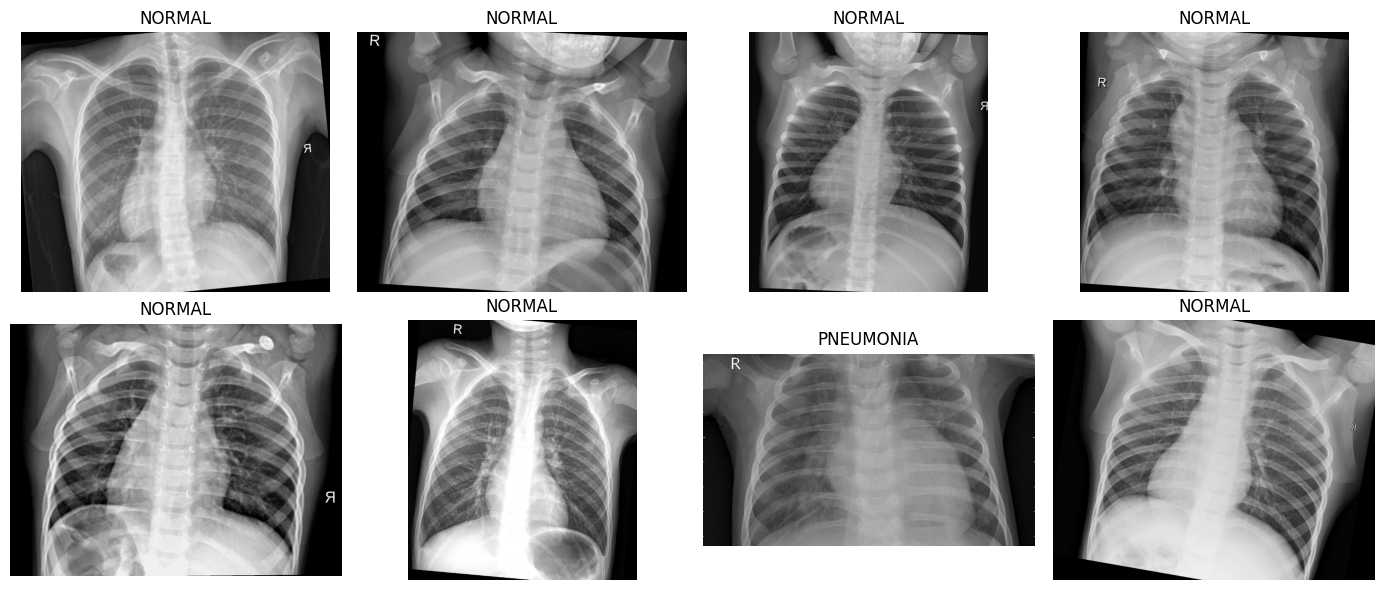

In [6]:
show_random_images(TRAIN_DIR, n=8)

## Check Image Size & Channels

In [7]:
sample_cls = sorted(os.listdir(TRAIN_DIR))[0]
sample_img = os.listdir(os.path.join(TRAIN_DIR, sample_cls))[0]
sample_path = os.path.join(TRAIN_DIR, sample_cls, sample_img)

img = tf.keras.utils.load_img(sample_path)
arr = tf.keras.utils.img_to_array(img)

print("Sample path:", sample_path)
print("Image shape:", arr.shape)

Sample path: dataset\train\NORMAL\IM-0001-0001.jpeg
Image shape: (1317, 1857, 3)


In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

## Train Augmentation

In [9]:
from tensorflow.keras.applications.vgg16 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function= preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode="nearest"
)

## Validation/Test Generator

In [10]:

test_val_datagen = ImageDataGenerator(preprocessing_function= preprocess_input)

## ##  Load Generators

In [11]:
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=True,
    seed=SEED
)

val_gen = test_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False
)

test_gen = test_val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 6800 images belonging to 2 classes.
Found 1700 images belonging to 2 classes.
Found 30 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


## Compute Class Weights

In [12]:
y_train = train_gen.classes
classes = np.unique(y_train)

weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {int(c): w for c, w in zip(classes, weights)}
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


## VGG16 model


In [13]:
from tensorflow.keras.applications import VGG16


In [14]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

model_vgg16 = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1,activation='sigmoid')

])

model_vgg16.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [15]:
model_vgg16.compile(optimizer='adam',
                    metrics=['accuracy'],
                    loss='binary_crossentropy'
                    )

In [16]:
history_vgg16 = model_vgg16.fit(train_gen,
                              validation_data=val_gen,
                              epochs= 3,
                              class_weight=class_weights,
                              verbose=1
                              )

Epoch 1/3
213/213 ━━━━━━━━━━━━━━━━━━━━ 614s 3s/step - accuracy: 0.8999 - loss: 0.2794 - val_accuracy: 0.9259 - val_loss: 0.1968
Epoch 2/3
213/213 ━━━━━━━━━━━━━━━━━━━━ 445s 2s/step - accuracy: 0.9441 - loss: 0.1484 - val_accuracy: 0.9541 - val_loss: 0.1282
Epoch 3/3
213/213 ━━━━━━━━━━━━━━━━━━━━ 446s 2s/step - accuracy: 0.9493 - loss: 0.1396 - val_accuracy: 0.9506 - val_loss: 0.1457


In [17]:
import numpy as np

# probabilities (0 → 1)
y_pred_prob = model_vgg16.predict(test_gen)

# convert to 0 or 1
y_pred = (y_pred_prob > 0.4).astype(int).flatten()

# true labels
y_true = test_gen.classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [18]:
print(classification_report(y_true, y_pred, target_names=["Normal", "Pneumonia"]))

              precision    recall  f1-score   support

      Normal       1.00      0.93      0.97        15
   Pneumonia       0.94      1.00      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[14  1]
 [ 0 15]]


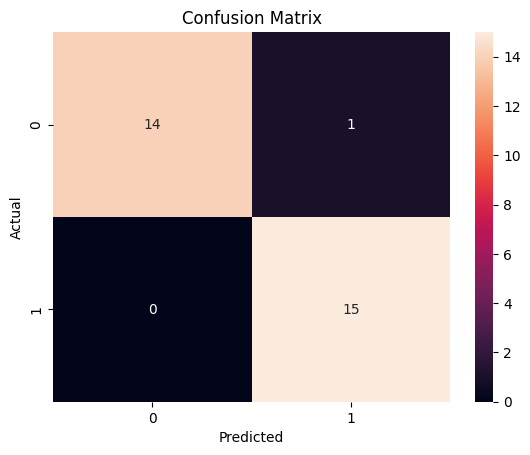

In [20]:
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9666666666666667


In [22]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, y_pred_prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.9911111111111112


In [23]:
model_vgg16.save("models/model_vgg16.keras")

## RESNET 50 

In [24]:
from tensorflow.keras.applications import ResNet50

In [25]:
base_model = ResNet50(
    weights ='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
for layer in base_model.layers:
    layer.trainable = False

In [26]:
model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
model_resnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [27]:
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [28]:
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=True,
    seed=SEED
)

val_gen = test_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False
)

test_gen = test_val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 6800 images belonging to 2 classes.
Found 1700 images belonging to 2 classes.
Found 30 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [29]:
model_resnet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
history_resnet = model_resnet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights,
    
    verbose=1
)

Epoch 1/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.9371 - loss: 0.1726 - val_accuracy: 0.9518 - val_loss: 0.1276
Epoch 2/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.9538 - loss: 0.1297 - val_accuracy: 0.9153 - val_loss: 0.2207
Epoch 3/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.9568 - loss: 0.1163 - val_accuracy: 0.9294 - val_loss: 0.1940
Epoch 4/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.9634 - loss: 0.0997 - val_accuracy: 0.9506 - val_loss: 0.1420
Epoch 5/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.9679 - loss: 0.0941 - val_accuracy: 0.9188 - val_loss: 0.2334


In [31]:
import numpy as np

# probabilities (0 → 1)
y_pred_prob = model_vgg16.predict(test_gen)

# convert to 0 or 1
y_pred = (y_pred_prob > 0.4).astype(int).flatten()

# true labels
y_true = test_gen.classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


In [32]:
print(classification_report(y_true, y_pred, target_names=["Normal", "Pneumonia"]))

              precision    recall  f1-score   support

      Normal       1.00      0.93      0.97        15
   Pneumonia       0.94      1.00      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[14  1]
 [ 0 15]]


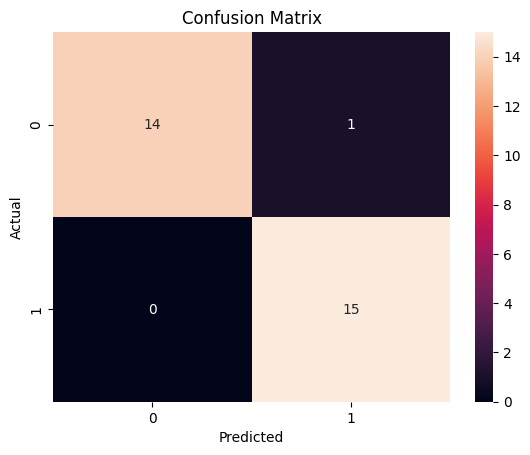

In [34]:
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9666666666666667


In [36]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, y_pred_prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.9911111111111112


In [37]:
model_resnet.save("models/model_resnet.keras")

## EfficientnetB0

In [38]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [39]:
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=True,
    seed=SEED
)

val_gen = test_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False
)

test_gen = test_val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 6800 images belonging to 2 classes.
Found 1700 images belonging to 2 classes.
Found 30 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [40]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Load base model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Build model
model_efficient = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_efficient.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [41]:
model_efficient.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [42]:
history_efficient = model_efficient.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - accuracy: 0.9112 - loss: 0.2179 - val_accuracy: 0.6118 - val_loss: 0.8433
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 304s 1s/step - accuracy: 0.9407 - loss: 0.1518 - val_accuracy: 0.6024 - val_loss: 1.0115
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - accuracy: 0.9432 - loss: 0.1496 - val_accuracy: 0.6165 - val_loss: 0.9313
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 300s 1s/step - accuracy: 0.9501 - loss: 0.1315 - val_accuracy: 0.6724 - val_loss: 0.8394
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.9488 - loss: 0.1315 - val_accuracy: 0.5906 - val_loss: 1.1990
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 347s 1s/step - accuracy: 0.9549 - loss: 0.1211 - val_accuracy: 0.7271 - val_loss: 0.6595
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.9526 - loss: 0.1160 - val_accuracy: 0.7518 - val_loss: 0.6745
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.9550 - loss: 0.1121 - val_accu

In [43]:
model_resnet.save("models/model_efficient.keras")